<a href="https://colab.research.google.com/github/vn322/bag_of_bats/blob/main/%D0%BC%D0%B0%D1%82%D0%B5%D0%BC%D0%B0%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%81%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Математическая статистика 3**

**Ключевые слова**: линейная регрессия, отстатки, градиентный спуск

**Программа лекции:**

1. Линейная регререссия
2. Предсказание
3. Остатки
4. Градиентный спуск
5. Train/test split

Одним из самых практичных методов анализа **данных** является построение линии через наблюдаемые точки для демонстрации связи между двумя или более переменными. **Регрессия** стремится **подогнать функцию** к **наблюдаемым данным**, чтобы потом сделать предсказание на **новых данных**. **Линейная регрессия** подгоняет **прямую линию** к наблюдаемым данным, стараясь показать линейную связь между **переменными** и сделать предсказание на новых **данных**. Чтобы лучше понять, что такое **линейная регрессия**, полезно посмотреть на пример на *рисунке 1*.

**Линейная регрессия** является основным инструментом в области данных и статистики и не только применяет концепции, изученные в предыдущих лекциях, но и является основой для таких тем, как **нейронные сети** и **логистическая регрессия**. Этот относительно простой метод существует уже более двухсот лет и сегодня считается базовым **методом машинного обучения**.

**Практики машинного обучения** часто используют другой подход к валидации, начав с разделения данных на **обучающую** и **тестовую выборки**. **Статистики** же чаще обращаются к метрикам, таким как интервал прогнозирования и корреляция, для определения статистической значимости. Мы рассмотрим оба подхода.

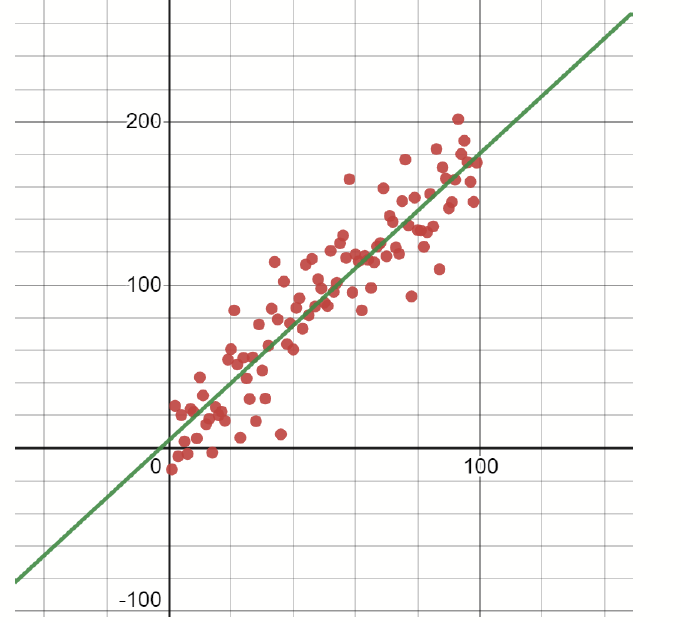

Рисунок 1. Пример построения линейной регрессии

# Простая линейная регрессия

Обратимся к конкретнуму примеру. Пусть мы хотим изучить зависимость между возрастом собаки и количеством посещений ею ветеринара за всю жизнь. В выборке у нас есть 10 случайных собак.  Давайте построим этот набор данных на графике, как показано на рисунке 2.


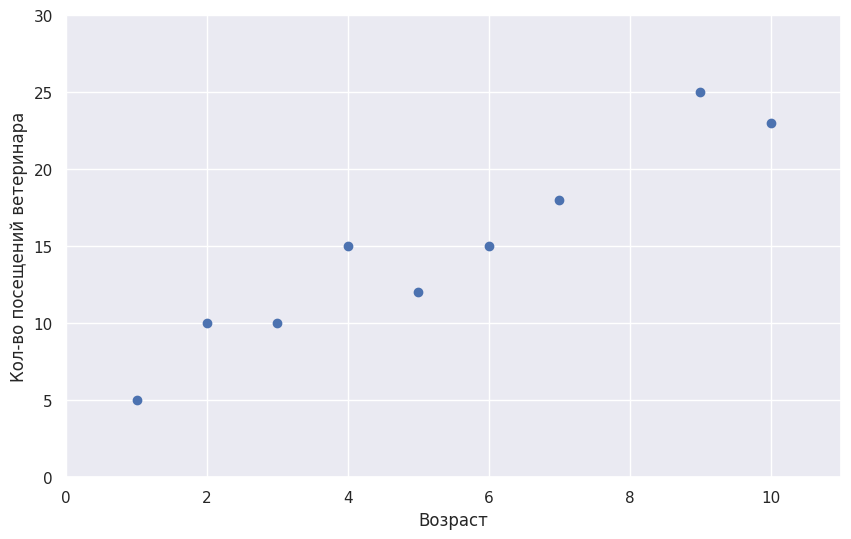

In [ ]:
#@title <b> Рисунок </b>
import pandas as pd
import matplotlib.pyplot as plt

# Создаем DataFrame
data = {
    "Возраст": [1, 2, 3, 4, 5, 6, 7, 9, 10],
    "Кол-во посещений ветеринара": [5, 10, 10, 15, 12, 15, 18, 25, 23]
}

df = pd.DataFrame(data)

# Строим график
plt.figure(figsize=(10, 6))
plt.scatter(df["Возраст"], df["Кол-во посещений ветеринара"], marker='o', linestyle='-', color='b', label='Посещения ветеринара')

# Устанавливаем названия осей и заголовок на русском
plt.xlabel('Возраст')
plt.ylabel('Кол-во посещений ветеринара')
#plt.title('Возраст и количество посещений ветеринара')
#plt.legend()
plt.ylim(0, 30)
plt.xlim(0, 11)

# Отображаем график
plt.grid(True)
plt.show()



Рисунок 2. Выборка из 10 собак с указанием их возраста и количества посещений ветеринара за всю жизнь.

Мы можем ясно видеть, что здесь существует **линейная корреляция**, что означает, что при увеличении/уменьшении одной из этих переменных, другая увеличивается/уменьшается пропорционально. Мы могли бы провести линию через эти точки, чтобы показать такую корреляцию, как показано на *рисунке 3*. Мы узнаем, как рассчитать эту **подогнанную линию** позже в этой лекции. Мы также изучим, как рассчитать качество этой подогнанной линии. Сейчас сосредоточимся на преимуществах выполнения линейной регрессии. Это позволяет нам делать прогнозы на основе данных, которые мы еще не видели. У нас нет собаки в выборке, которой **8,5** лет, но мы можем посмотреть на эту линию и предположить, что у собаки будет **21** визит к ветеринару в её жизни. Мы просто смотрим на линию, где $\mathbf{x = 8,5}$ и видим, что $\mathbf{y = 21.218}$ как показано на *рисунке 4*. Еще одно преимущество — мы можем анализировать переменные на предмет возможных отношений и предполагать, что коррелирующие переменные имеют **причинно-следственную связь**.

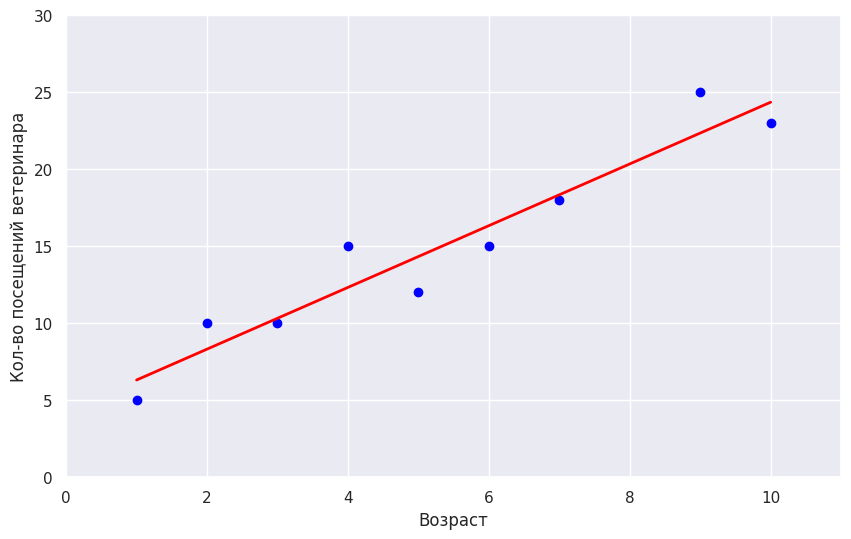

In [ ]:
#@title <b> Рисунок </b>
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Создаем DataFrame
data = {
    "Возраст": [1, 2, 3, 4, 5, 6, 7, 9, 10],
    "Кол-во посещений ветеринара": [5, 10, 10, 15, 12, 15, 18, 25, 23]
}

df = pd.DataFrame(data)

# Обучаем модель линейной регрессии
X = df[["Возраст"]]
y = df["Кол-во посещений ветеринара"]
model = LinearRegression()
model.fit(X, y)

# Предсказываем значения на основе модели
x_range = np.linspace(df["Возраст"].min(), df["Возраст"].max(), 100).reshape(-1, 1)
y_pred = model.predict(x_range)

# Построение графика
plt.figure(figsize=(10, 6))
plt.scatter(df["Возраст"], df["Кол-во посещений ветеринара"], color='blue', label='Данные')
plt.plot(x_range, y_pred, color='red', linewidth=2, label='Линейная регрессия')

# Устанавливаем названия осей и заголовок на русском
plt.xlabel('Возраст')
plt.ylabel('Кол-во посещений ветеринара')
#plt.title('Возраст и количество посещений ветеринара')
#plt.legend()
plt.ylim(0, 30)
plt.xlim(0, 11)

# Отображаем график
plt.grid(True)
plt.show()



Рисунок 3. Подгонка наших данных с помощью прямой линии

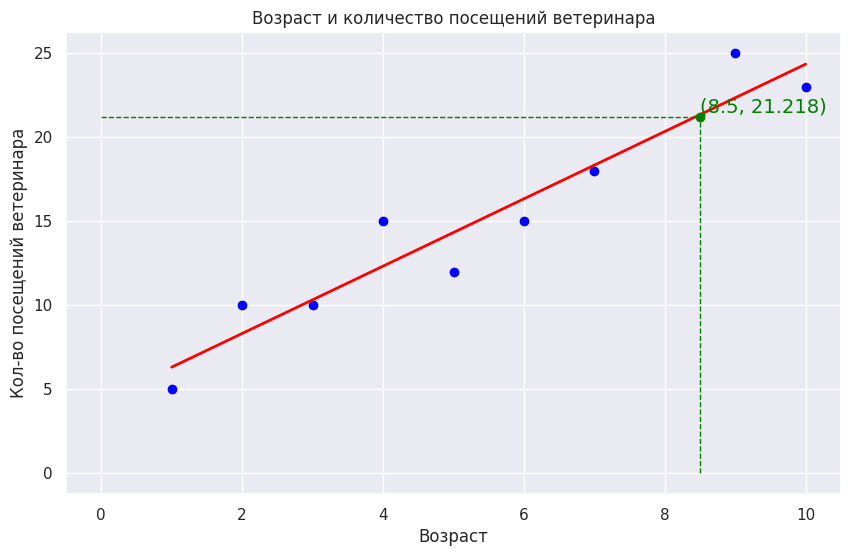

In [ ]:
#@title <b> Рисунок </b>
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Создаем DataFrame
data = {
    "Возраст": [1, 2, 3, 4, 5, 6, 7, 9, 10],
    "Кол-во посещений ветеринара": [5, 10, 10, 15, 12, 15, 18, 25, 23]
}

df = pd.DataFrame(data)

# Обучаем модель линейной регрессии
X = df[["Возраст"]]
y = df["Кол-во посещений ветеринара"]
model = LinearRegression()
model.fit(X, y)

# Предсказываем значения на основе модели
x_range = np.linspace(df["Возраст"].min(), df["Возраст"].max(), 100).reshape(-1, 1)
y_pred = model.predict(x_range)

# Построение графика
plt.figure(figsize=(10, 6))
plt.scatter(df["Возраст"], df["Кол-во посещений ветеринара"], color='blue', label='Данные')
plt.plot(x_range, y_pred, color='red', linewidth=2, label='Линейная регрессия')

# Добавляем точку (8.5, 21.218) и соединяем ее с осями
x_point = 8.5
y_point = 21.218
plt.scatter([x_point], [y_point], color='green', zorder=5)
plt.plot([x_point, x_point], [0, y_point], color='green', linestyle='--', linewidth=1)
plt.plot([0, x_point], [y_point, y_point], color='green', linestyle='--', linewidth=1)

# Добавляем метку с координатами точки
plt.text(x_point, y_point, f'({x_point}, {y_point})', fontsize=14, ha='left', va='bottom', color='green')

# Устанавливаем названия осей и заголовок на русском
plt.xlabel('Возраст')
plt.ylabel('Кол-во посещений ветеринара')
plt.title('Возраст и количество посещений ветеринара')
#plt.legend()

# Отображаем график
plt.grid(True)
plt.show()

Рисунок 4. Делаем прогноз с помощью линейной регрессии. **8,5**-летняя собака по прогнозам посетит ветирана **21,2** раз за всю жизнь

Теперь какие недостатки у **линейной регрессии**? Мы не можем ожидать, что каждый результат будет точно попадать на эту линию. В конце концов, данные реального мира шумные и никогда не идеальны и не будут следовать **прямой линии**. Они могут вообще не следовать **прямой линии**! Вокруг этой линии будет погрешность, где точки будут находиться выше или ниже линии. Еще одной проблемой является то, что мы не должны использовать линейную регрессию для прогнозирования за пределами диапазона данных, которые у нас есть, то есть мы не должны делать прогнозы при $x < 0$ и $x > 10$, потому что у нас нет данных за пределами этих значений.

В этой лекции мы будем использовать **Python** и начинем с модуля **scikit-learn**, который сделает всю работу за нас. Позже будет показано, как построить линейную регрессию "с нуля".

*Пример 1* показывает, как использовать **scikit-learn** для выполнения линейной регрессии на примере выборки из **10** собак. Мы импортируем эти данные с помощью **Pandas**, конвертируем их в массивы **NumPy**, выполняем линейную регрессию с помощью **scikit-learn** и cначала мы импортируем данные из **CSV** на **GitHub**. Мы разделим две колонки на наборы данных **X** и **Y**, используя Pandas. Затем мы подгоним модель **LinearRegression** на входные данные **X** и выходные данные **Y**. Затем мы можем получить коэффициенты **m** и **b**, которые описывают нашу подогнанную линейную функцию.

m = [1.93939394]
b = [4.73333333]


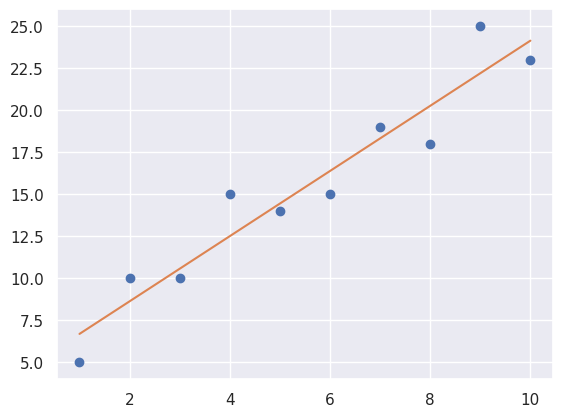

In [ ]:
# Пример 1
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Импорт данных
df = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")
# Извлечение входных переменных (все строки, все колонки кроме последней)
X = df.values[:, :-1]
# Извлечение выходной колонки (все строки, последняя колонка)
Y = df.values[:, -1]

fit = LinearRegression().fit(X, Y)
# m = 1.7867224, b = -16.51923513
m = fit.coef_.flatten()
b = fit.intercept_.flatten()
print("m = {0}".format(m))
print("b = {0}".format(b))

# Строим график
plt.plot(X, Y, 'o') # точки
plt.plot(X, m*X+b) # линия
plt.show()

На графике, конечно, мы получили подогнанную линию, аппроксимирующую данные. Что определяет лучшую подгонку линии к этим точкам? Обсудим это далее.

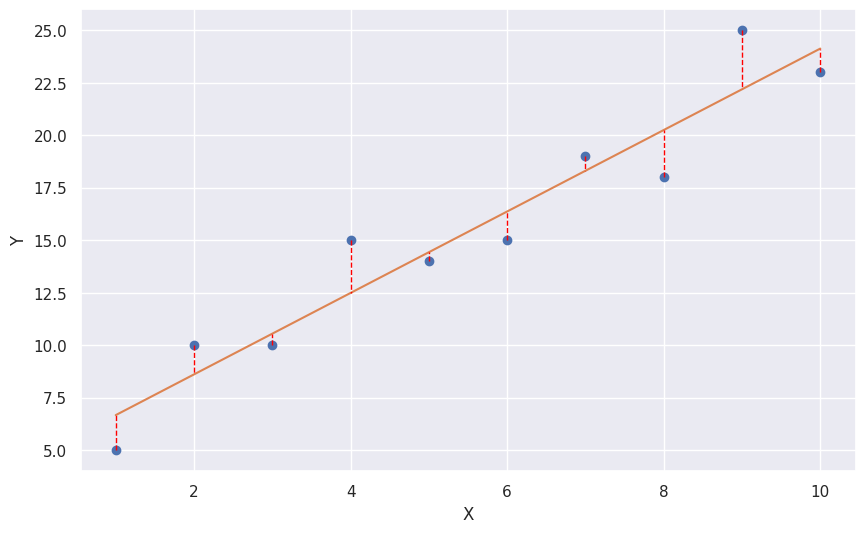

In [ ]:
#@title <b> Рисунок </b>
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Импорт данных
df = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")
# Извлечение входных переменных (все строки, все колонки кроме последней)
X = df.values[:, :-1]
# Извлечение выходной колонки (все строки, последняя колонка)
Y = df.values[:, -1]


# Обучаем модель линейной регрессии
fit = LinearRegression().fit(X, Y)
# Коэффициенты
m = fit.coef_.flatten()
b = fit.intercept_.flatten()
#print("m = {0}".format(m))
#print("b = {0}".format(b))

# Предсказанные значения
Y_pred = fit.predict(X)

# Построение графика линейной регрессии с остатками
plt.figure(figsize=(10, 6))

# График линейной регрессии
plt.plot(X, Y, 'o', label='Данные')  # точки
plt.plot(X, Y_pred, label='Линейная регрессия')  # линия

# Добавление линий остатков
for i in range(len(X)):
    plt.plot([X[i], X[i]], [Y[i], Y_pred[i]], color='red', linestyle='--', linewidth=1)

# Устанавливаем названия осей и заголовок
plt.xlabel('X')
plt.ylabel('Y')
#plt.title('Линейная регрессия с остатками')
#plt.legend()

# Отображаем график
plt.grid(True)
plt.show()



Рисунок 5. Остатки — это разности между "линией и точками".

# Остатки

Точки выше линии имеют **положительный остаток**, а точки ниже линии — **отрицательный**. Иными словами, это разница между предсказанными значениями y (по уравнению линии) и фактическими значениями y (из данных). Остатки также называют **ошибками**, поскольку они показывают, насколько линия ошибается в предсказании данных.

Рассчитаем эти различия для **10** точек и линии $y = 1.93939x + 4.73333$ в *примере 2*. Если мы проводим прямую линию через **10** точек данных, нам нужно минимизировать эти остатки в целом, чтобы максимально уменьшить разрыв между линией и точками. Но как измерить это «общее отклонение»? Лучший способ — использовать сумму квадратов остатков. Мы возводим каждый остаток в квадрат, получая положительные значения, и складываем их. Это делается путем вычитания предсказанного $y_{predict}$ из фактического $y_{actual}$ для каждой точки, возведения разницы в квадрат и сложения всех этих значений.

In [ ]:
# Пример 2. Расчет остатков
import pandas as pd

points = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",").itertuples()

m = 1.93939
b = 4.73333

for p in points:
    y_actual = p.y
    y_predict = m * p.x + b
    print(y_actual - y_predict)

-1.67272
1.3878900000000005
-0.5515000000000008
2.5091099999999997
-0.4302799999999998
-1.3696699999999993
0.6909400000000012
-2.2484499999999983
2.812160000000002
-1.1272299999999973


# Почему не использовать абсолютные значения?

Вы можете задаться вопросом, почему мы возводим **остатки** в квадрат перед их суммированием. Почему бы просто не сложить их как есть, без возведения в квадрат? Это не сработает, потому что отрицательные значения будут отменять положительные. Может сложим абсолютные значения, где все отрицательные значения превращаются в положительные? Это звучит логично, но использование абсолютных значений математически неудобно. Точнее говоря, абсолютные значения плохо сочетаются с производными, которые мы будем использовать позднее для градиентного спуска. Вот почему мы выбираем квадраты остатков в качестве способа суммирования ошибок.

In [ ]:
# Пример 3. Сумма квадртов остатков
import pandas as pd

points = pd.read_csv("https://bit.ly/2KF29Bd").itertuples()

m = 1.93939
b = 4.73333
sum_of_squares = 0.0

for p in points:
  y_actual = p.y
  y_predict = m*p.x + b
  residual_squared = (y_predict - y_actual)**2
  sum_of_squares += residual_squared
print("sum of squares = {}".format(sum_of_squares))

sum of squares = 28.096969704500005


Как модули **статистики**, такие как **scikit-learn**, находят линию, которая наилучшим образом соответствует данным точкам? Этот процесс сводится к двум основным вопросам машинного обучения:

- Что определяет «наилучшее соответствие»?

- Как мы достигаем этого «наилучшего соответствия»?

Ответ на первый вопрос: необходимо **минимизировать сумму** квадратов остатков.


Вы можете задаться вопросом, почему мы должны возводить в **квадрат остатки** перед их суммированием. Почему не просто сложить их без возведения в квадрат? Это не сработает, потому что отрицательные значения будут компенсировать положительные значения. Что если сложить абсолютные значения, где мы превращаем все отрицательные значения в положительные? Это звучит многообещающе, но абсолютные значения математически неудобны. Более конкретно, абсолютные значения плохо работают с производными, которые мы будем использовать позже для градиентного спуска. Вот почему используем остатки в квадрате, как наш способ суммирования потерь.




# Нахождение "наилучшей" линии

Теперь у нас есть способ измерить качество заданной линии относительно точек данных: сумма квадратов. Чем меньше это число, тем лучше соответствие. Но как найти правильные значения $m$ (наклон прямой) и $b$ (смещение прямой), которые минимизируют сумму квадратов?

Существует несколько алгоритмов поиска, которые можно использовать для нахождения нужных значений для решения данной задачи. Можно попробовать метод грубой силы, генерируя случайные значения $m$ и $b$ миллионы раз и выбирая те, которые дают наименьшую сумму квадратов. Однако это неэффективно, так как найдет даже приблизительное решение за бесконечно долгое время. Нам нужен более направленный подход. Мы представим пять техник, которые можно использовать: **замкнутая форма**, **обратная матрица**, **матричное разложение**, **градиентный спуск** и **стохастический градиентный спуск**.

# Аналитическое решение

Некоторые  могут спросить, существует ли **формула** (называемая уравнением замкнутой формы) для точного расчета **линейной регрессии**. Ответ — да, но только для **простой линейной регрессии с одной входной переменной**. Такой формулы не существует для многих задач машинного обучения с несколькими входными переменными и большим объемом данных.

Для простой **линейной регрессии** с одной входной и одной выходной переменной вот уравнения замкнутой формы для расчета $m$ и $b$. *Пример 4* показывает, как можно выполнить эти расчеты на **Python**.

$$
m = \frac{n\sum{xy} - \sum{x}\sum{y}}{n\sum{x^2} - (\sum{x})^2}
$$

$$
b = \frac{\sum{y}}{n} - m \frac{\sum{x}}{n}
$$

Эти уравнения для расчета $m$ и $b$ выведены из математического анализа, и позже в этой главе мы воспользуемся SymPy для выполнения некоторых операций анализа, если вам захочется узнать, откуда берутся формулы. А пока можно подставить количество точек данных $n$ и итеративно выполнить операции с $x$ и $y$ для выполнения описанных выше операций.

Двигаясь дальше, мы будем изучать подходы, которые больше ориентированы на современные техники, справляющиеся с **большими объемами данных**. Уравнения замкнутой формы **обычно плохо масштабируются**.

In [ ]:
# Пример 4.
import pandas as pd

# Загрузка данных
points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())

n = len(points)
m = (n * sum(p.x * p.y for p in points) - sum(p.x for p in points) *
     sum(p.y for p in points)) / (n * sum(p.x**2 for p in points) -
     sum(p.x for p in points)**2)
b = (sum(p.y for p in points) / n) - m * sum(p.x for p in points) / n

print(m, b)
# 1.9393939393939394 4.7333333333333325

1.9393939393939394 4.7333333333333325


# Обратная матрица

В дальнейшем мы иногда будем заменять коэффициенты m и b разными именами, соответственно, $β_1$ и $β_0$. Это общепринятые обозначения, которые чаще встречаются в профессиональной среде, поэтому сейчас хорошее время начать их использовать.

Мы можем использовать транспонированные и обратные матрицы, которые мы рассмотрели в лекциях по линейной алгебре, чтобы выполнить линейную регрессию. Далее мы вычислим вектор коэффициентов $\beta$, если у нас есть матрица значений входных переменных $X$ и вектор значений выходных переменных $y$. Не вдаваясь в детали математического анализа и доказательств линейной алгебры, вот формула:

$ \beta = (X^T \cdot X)^{-1} \cdot X^T \cdot y $

Вы заметите, что над матрицей $X$ выполняются операции транспонирования и обращения, которые затем комбинируются с умножением матриц. Вот как мы выполняем эту операцию в **NumPy** в *примере 5* для получения наших коэффициентов $m$ и $b$.


In [ ]:
# Пример 5: Использование обратных и транспонированных матриц для выполнения линейной регрессии
import pandas as pd
from numpy.linalg import inv
import numpy as np

# Импорт точек
df = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

# Извлечение входных переменных (все строки, все столбцы кроме последнего)
X = df.values[:, :-1].flatten()

# Добавление столбца "1" для генерации перехвата
X_1 = np.vstack([X, np.ones(len(X))]).T

# Извлечение выходного столбца (все строки, последний столбец)
Y = df.values[:, -1]

# Вычисление коэффициентов наклона и перехвата
beta = inv(X_1.T @ X_1) @ (X_1.T @ Y)

print(beta)  # [1.93939394, 4.73333333]

# Предсказание значений y
y_predict = X_1.dot(beta)

[1.93939394 4.73333333]


# Метод матричного разложения (QR)

Когда у вас много данных с множеством измерений, компьютеры могут сталкиваться с трудностями и выдавать нестабильные результаты. В данном случае мы берем нашу матрицу $X$, добавляем дополнительный столбец из единиц для генерации пересечения $\beta_0$, а затем разлагаем её на две составляющие матрицы $Q$ и $R$:

$$
X = Q \cdot R
$$

Избегая более глубоких рассуждений, вот как мы используем $Q$ и $R$ для нахождения значений коэффициентов бета в матричной форме:

$$\beta = R^{-1} \cdot Q^T \cdot y$$

*Пример 6* показывает, как использовать предшествующую формулу для разложения **QR** в **Python** с использованием **NumPy** для выполнения **линейной регрессии**. Обычно метод разложения **QR** используется многими научными библиотеками для линейной регрессии, так как он легче справляется с большим объемом данных и более устойчив.  



In [ ]:
#Пример 6. Использование QR разложения для выполнения линейной регрессии
import pandas as pd
from numpy.linalg import qr, inv
import numpy as np

# Импорт данных
df = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

# Извлечение входных переменных (все строки, все столбцы кроме последнего)
X = df.values[:, :-1].flatten()

# Добавление столбца "1" для генерации перехвата
X_1 = np.vstack([X, np.ones(len(X))]).T

# Извлечение выходного столбца (все строки, последний столбец)
Y = df.values[:, -1]

# Вычисление коэффициентов наклона и перехвата
# используя QR разложение
Q, R = qr(X_1)
b = inv(R).dot(Q.T).dot(Y)

print(b)  # [1.93939394, 4.73333333]

[1.93939394 4.73333333]


# Градиентный спуск и линейная регрессия

Теперь вы можете задаться вопросом, как использовать это для линейной регрессии. Ну, это та же идея, за исключением того, что нашими «переменными» являются $m$ и $b$ или $\beta_0$ и $\beta_1$, а не $x$. Вот почему: в простой линейной регрессии мы уже знаем значения $x$ и $y$, потому что они предоставлены в качестве обучающих данных. «Переменными», которые мы должны решить, являются фактически параметры $m$ и $b$, чтобы найти наилучшую прямую линию.

В математической нотации, где $e(x)$ представляет собой функцию потерь суммы квадратов, вот частные производные для $m$ и $b$:

$$
\frac{d}{dm} e(x) = \sum_{i=0}^{n} (2 \cdot (b + m \cdot x[i] - y[i]) \cdot x[i])
$$

$$
\frac{d}{db} e(x) = \sum_{i=0}^{n} (2 \cdot (b + m \cdot x[i] - y[i]))
$$

Затм мы применяем градиентный спуск как в лекции 2 по математическому анализу.


# Стохастический градиентный спуск

На практике редко используются полный **градиентный спуск**. Вы скорее будете использовать **стохастический градиентный спуск**, который будет обучаться на одной выборке из данных за итерацию. В мини-пакетном градиентном спуске используется несколько выборок (*англ. batch*) из данных (например, 10 или 100 точек) за итерацию.

Почему используют только часть данных за итерацию? Специалисты по машинному обучению приводят несколько преимуществ. Во-первых, это значительно снижает вычислительную нагрузку, так как каждая итерация не должна проходить по всему тренировочному набору данных, а только по его части. Второе преимущество - это снижение переобучения. Обучение алгоритма только на части данных за каждую итерацию постоянно меняет "ландшафт ошибки", не позволяя ему зафиксироваться в минимуме ошибке.

*Пример 7* показывает, как выполнить стохастический градиентный спуск на Python. Если изменить размер выборки больше 1, то будет выполнен пакетный градиентный спуск.

In [ ]:
# Пример 7. Выполнение стохастического градиентного спуска для линейной регрессии
import pandas as pd
import numpy as np

# Входные данные
data = pd.read_csv('https://bit.ly/2KF29Bd', header=0)
X = data.iloc[:, 0].values
Y = data.iloc[:, 1].values
n = data.shape[0]  # количество строк

# Построение модели
m = 0.0
b = 0.0
sample_size = 1  # размер выборки
L = .0001  # шаг обучения
epochs = 1_000_000  # количество итераций для градиентного спуска

# Выполнение стохастического градиентного спуска
for i in range(epochs):
    idx = np.random.choice(n, sample_size, replace=False)
    x_sample = X[idx]
    y_sample = Y[idx]

    # текущие предсказанные значения Y
    Y_pred = m * x_sample + b

    # частная производная потерь по m
    D_m = (-2 / sample_size) * sum(x_sample * (y_sample - Y_pred))
    # частная производная потерь по b
    D_b = (-2 / sample_size) * sum(y_sample - Y_pred)

    # обновление m и b
    m -= L * D_m
    b -= L * D_b

    # печать прогресса каждые 10 000 итераций
    if i % 10000 == 0:
        print(i, m, b)

print("y = {0}x + {1}".format(m, b))

0 0.028800000000000003 0.0036000000000000003
10000 2.3486037611885577 1.8625780863236252
20000 2.1654497833589748 2.837916909098544
30000 2.083224017855991 3.4973318660310557
40000 2.063670114438216 3.8963189510322294
50000 2.024648658558415 4.173949246057954
60000 1.9899045701246292 4.363725138126644
70000 1.9875866344122435 4.489740059096745
80000 1.9745748708723705 4.572538486390598
90000 1.9572053550847641 4.625247066602355
100000 1.9419241823921656 4.6707455354564065
110000 1.9275647429952043 4.678654243332469
120000 1.9568411041088571 4.690600261679913
130000 1.9612889152347677 4.696950080847853
140000 1.9485843344208464 4.69815864681412
150000 1.9375520105010693 4.71152032027703
160000 1.9659605010052004 4.728088693553376
170000 1.9433649529503556 4.727111575404082
180000 1.96035587933865 4.729428261534409
190000 1.9760501347659631 4.729064462488639
200000 1.9887052504494103 4.750289874610097
210000 1.9874662161956953 4.744788278564348
220000 1.972625502613468 4.753138888730045


Когда я запустил это, я получил линейную регрессию $y = 1.921x + 4.7379$. Очевидно, ваши результаты будут другими, и из-за стохастического градиентного спуска мы не будем сходиться к определенному минимуму, а будем находиться в более широком диапазоне.

# Переобучение и дисперсия

Вопрос к нам: если бы мы действительно хотели **минимизировать ошибки**, как, например, уменьшить сумму квадратов до **0**, что бы мы делали? Есть ли у нас другие варианты, кроме **линейной регрессии**? Один из выводов, к которым вы можете прийти, - это просто провести кривую, которая пройдет через все точки. Почему бы просто не соединить точки сегментами и не использовать получившуюся **кусочно-линейную фунцию** для предсказаний, как показано на *рисунке 6*? Это даст нам нулевую ошибку!

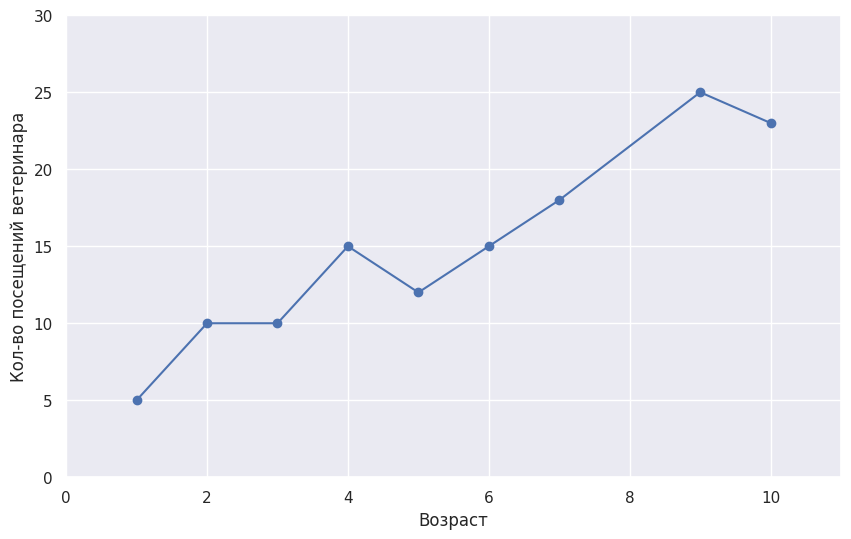

In [ ]:
#@title <b> Рисунок </b>
import pandas as pd
import matplotlib.pyplot as plt

# Создаем DataFrame
data = {
    "Возраст": [1, 2, 3, 4, 5, 6, 7, 9, 10],
    "Кол-во посещений ветеринара": [5, 10, 10, 15, 12, 15, 18, 25, 23]
}

df = pd.DataFrame(data)

# Строим график
plt.figure(figsize=(10, 6))
plt.scatter(df["Возраст"], df["Кол-во посещений ветеринара"], marker='o', color='b', label='Посещения ветеринара')

# Соединяем точки линиями
plt.plot(df["Возраст"], df["Кол-во посещений ветеринара"], linestyle='-', color='b')

# Устанавливаем названия осей и заголовок на русском
plt.xlabel('Возраст')
plt.ylabel('Кол-во посещений ветеринара')
#plt.title('Возраст и количество посещений ветеринара')
#plt.legend()
plt.ylim(0, 30)
plt.xlim(0, 11)

# Отображаем график
plt.grid(True)
plt.show()



Рисунок 6. Выполнение регрессии путем простого соединения точек, в результате чего получается нулевая ошибка.

Почему же мы так мучились с **линейной регрессией**, а не сделали это? Помните, наша цель - не просто **минимизировать сумму квадратов**, а делать точные предсказания на новых данных. Подход "соединения точек" сильно переобучен, что значит, что он слишком точно подогнан к **тренировочным данным** и будет делать **плохие предсказания** на новых данных. Этот простой метод соединения точек чувствителен к выбросам, которые далеко от остальных точек, что означает, что предсказания будут иметь высокую дисперсию. В нашем примере точки относительно близки к линии, но эта проблема становится больше с другими наборами данных с более широко разбросанными значениями и выбросами. Поскольку переобучение увеличивает дисперсию, предсказания будут очень изменчивыми!

Именно поэтому в машинном обучении вы добавляете **смещение** (*англ. bias*) в модель, и линейная регрессия считается моделью с высоким смещением.  Смещение в модели означает, что мы приоритизируем метод (например, поддержание прямой линии), а не изгибание и точное подгонка к данным. Модель со **смещением** оставляет некоторую свободу, надеясь минимизировать ошибки на новых данных, а не минимизировать ошибки на данных, по которым она обучалась. Можно сказать, что добавление **смещения** в модель противодействует переобучению недообучением, то есть меньшей подгонкой к обучающим данным.

# Kоэффициент корреляции

Посмотрите на *рисунок 7* с его линейной регрессией. Почему линейная регрессия может здесь не очень хорошо работать? Проблема в том, что данные имеют высокую **дисперсию**. Если данные сильно разбросаны, это увеличивает **дисперсию**, что приводит к менее точным и полезным предсказаниям, с большими остатками.

Конечно, мы можем ввести более смещенную модель, такую как линейная регрессия, чтобы не слишком реагировать на дисперсию. Однако недообучение также испортит наши предсказания, поскольку данные так сильно **разбросаны**. Нам нужно численно измерить, насколько "ошибочны" наши предсказания в совокупности. Как измерить эти остатки в совокупности? Как получить представление о том, насколько велика **дисперсия** в данных?

Коэффициент корреляции, также называемый корреляцией Пирсона, который измеряет силу связи между двумя переменными в виде значения от **-1** до **1**. Коэффициент корреляции, близкий к **0**, указывает на отсутствие корреляции. Коэффициент корреляции, близкий к **1**, указывает на сильную **положительную** корреляцию, что означает, что когда одна переменная увеличивается, другая пропорционально увеличивается. Если он близок к **-1**, это указывает на сильную **отрицательную корреляцию**, что означает, что когда одна переменная увеличивается, другая пропорционально уменьшается.

Обратите внимание, что **коэффициент корреляции** часто обозначается как $r$. Сильно рассеянные данные на *рисунке 7* имеют коэффициент корреляции 0.1201. Поскольку он намного ближе к **0**, чем к **1**, мы можем сделать вывод, что данные имеют слабую корреляцию.

Вот еще четыре графика рассеяния на *рисунке 8*, показывающие их **коэффициенты корреляции**. Обратите внимание, что чем ближе точки к линии, тем сильнее **корреляция**. Чем больше точки разбросаны, тем слабее **корреляция**.

**Коэффициент корреляции** полезен для определения, есть ли возможная связь между двумя переменными. Если существует **сильная положительная** или **отрицательная связь**, это будет полезно в нашей **линейной регрессии**. Если связи нет, они могут просто добавлять шум и снижать точность модели.





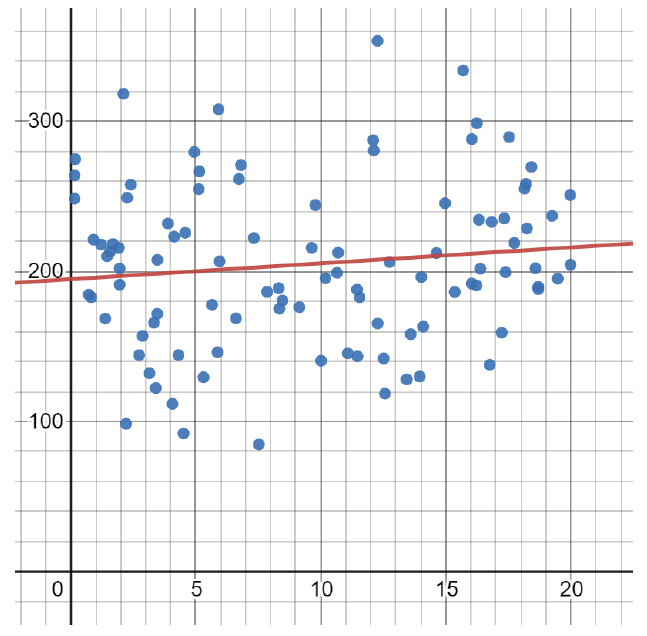

Рисунок 7. Данные с высокой дисперсией (разбросом)

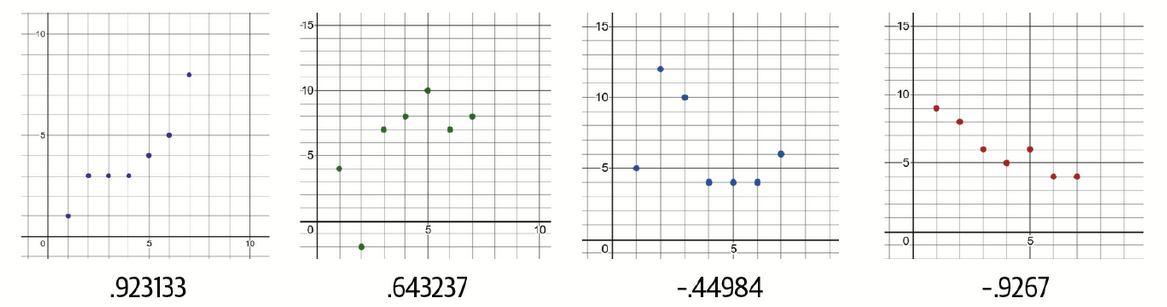

Рисунок 8. Коэффициенты соответствуют четырем типам данных

Как использовать **Python** для вычисления **коэффициента корреляции**? Давайте используем простой набор данных из **10** точек, который мы использовали ранее. Быстрый и легкий способ анализировать корреляции для всех пар переменных - использование функции `corr()` из Pandas. Это позволяет легко увидеть коэффициент корреляции между каждой парой переменных в наборе данных, в данном случае это будут только $x$ и $y$. Это называется матрицей корреляции. Посмотрите на *примере 8*.


In [ ]:
# Пример 8. Использование Pandas для просмотра коэффициента корреляции между каждой парой переменных
# Чтение данных в Pandas DataFrame
df = pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",")

# Печать корреляций между переменными
correlations = df.corr(method='pearson')
print(correlations)
# OUTPUT:
#           x         y
# x  1.000000  0.957586
# y  0.957586  1.000000

          x         y
x  1.000000  0.957586
y  0.957586  1.000000


Как видите, коэффициент корреляции **0.957586** между $x$ и $y$ указывает на сильную **положительную корреляцию** между этими двумя переменными. Вы можете проигнорировать части матрицы, где $x$ или $y$ представлены сами собой с значением $1.0$. Очевидно, что при сравнении $x$ или $y$ с самими собой корреляция будет идеальной (1.0), так как значения точно совпадают. Когда у вас больше двух переменных, матрица корреляции будет показывать большую сетку, так как будет больше переменных для сравнения.

Если вы измените код для использования другого набора данных с большой **дисперсией**, где данные сильно разбросаны, вы увидите, что **коэффициент корреляции уменьшается**. Это снова указывает на **слабую корреляцию**.

# Вычисление коэффициента корреляции

Вот формула для вычисления коэффициента корреляции:

$$
r = \frac{n\sum{xy} - \sum{x} \sum{y}}{\sqrt{(n\sum{x^2} - (\sum{x})^2) (n\sum{y^2} - (\sum{y})^2)}}
$$

*Пример 9* показывает реализацию коэффициента корреляции на Python с нуля:


In [ ]:
# Пример 9 Вычисление коэффициента корреляции с нуля на Python
import pandas as pd
from math import sqrt

# Импорт точек из CSV
points = list(pd.read_csv("https://bit.ly/2KF29Bd").itertuples())

n = len(points)
numerator = n * sum(p.x * p.y for p in points) - sum(p.x for p in points) * sum(p.y for p in points)
denominator = sqrt((n * sum(p.x**2 for p in points) - sum(p.x for p in points)**2) * (n * sum(p.y**2 for p in points) - sum(p.y for p in points)**2))

corr = numerator / denominator
print(corr)
# OUTPUT:
# 0.9575860952087218

0.9575860952087218


### Коэффициент детерминации
Коэффициент детерминации, называемый $r^2$, измеряет, насколько изменчивость одной переменной объяснима изменчивостью другой переменной. Это также квадрат коэффициента корреляции r. По мере приближения r к идеальной корреляции (-1 или 1), $r^2$ приближается к 1, показывая насколько две переменные взаимодействуют друг с другом.

Продолжая работу с данными (*рисунок 6*), в *примере 10* используем dataframe для расчета коэффициента корреляции и возводим его в квадрат.

Коэффициент детерминации равен **0.916971**, что означает, что **91.6971%** вариации в $x$ объясняется y (и наоборот), и оставшиеся **8.3029%** остаются неучтенными переменными. Коэффициент детерминации **0.91697**1 указывает на значительное взаимодействие $x$ и $y$. Однако, возможно, существуют другие переменные, которые не учтены и объясняют оставшуюся долю вариации. Помните, что корреляция не равна наличию причинно-следственной связи.



In [ ]:
# Пример 10. Создание матрицы корреляции в Pandas
import pandas as pd
# Чтение данных в Pandas dataframe
df = pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",")
# Вывод коэффициентов детерминации между переменными
coeff_determination = df.corr(method='pearson') ** 2
print(coeff_determination)
# Вывод:
#         x         y
# x  1.000000  0.916971
# y  0.916971  1.000000

          x         y
x  1.000000  0.916971
y  0.916971  1.000000


# Стандартная ошибка оценки
Для измерения общей погрешности линейной регрессии используется SSE (*aнгл. sum of squared errors - сумма квадратов ошибок*). SSE вычисляется как сумма квадратов отклонений предсказанных значений от реальных.

$$
SSE = Σ (y - \hat{y})^2
$$

Чтобы масштабы вернулись к исходным единицам, мы используем квадратный корень и среднее значение, дающее стандартную ошибку оценки (*англ. standard error - SE*).

$$
SE = \frac{Σ (y - \hat{y})^2}{n - 2}
$$

Использование $n-2$ вместо $n-1$ связано с наличием двух переменных в линейной регрессии, что требует увеличения неопределенности на одну степень свободы.

In [ ]:
# Пример 11. Вычисление стандартной ошибки оценки
import pandas as pd
from math import sqrt

# Загрузка данных
points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())
n = len(points)

# Линия регрессии
m = 1.939
b = 4.733

# Вычисление стандартной ошибки оценки
S_e = sqrt((sum((p.y - (m*p.x +b))**2 for p in points))/(n-2))
print(S_e)
# 1.87406793500129

1.87406793500129


# Разделение на обучающую и тестовую выборки

Этот анализ, который мы только что провели с корреляционным коэффициентом, и коэффициентом детерминации, к сожалению, не всегда выполняется практиками. Иногда они сталкиваются с таким огромным объемом данных, что у них просто нет времени или технической возможности это сделать. Например, изображение размером **128 × 128** пикселей содержит как минимум **16,384** переменных. У вас есть время проводить статистический анализ для каждой из этих переменных пикселей? Вероятно, нет!

К сожалению, это приводит к тому, что многие специалисты по данным вообще не изучают эти статистические метрики. Можно сказать **статистическая регрессия** — это **скальпель**, а **машинное обучение** — это **бензопила**. Работая с огромными объемами **данных** и **переменных**, невозможно просеять все это с помощью скальпеля. Приходится использовать **бензопилу**, и, хотя теряется объяснимость и точность, вы, по крайней мере, сможете масштабироваться и делать более широкие прогнозы на большем объеме данных. Тем не менее, такие статистические проблемы, как предвзятость выборки и переобучение, не исчезают. Но существуют несколько практик, которые можно применить для быстрой проверки.

Основной метод, который используют практики машинного обучения для уменьшения переобучения, называется разделение на **обучающую** и **тестовую выборки** (train/test split), при котором обычно 1/3 данных откладывается для тестирования, а остальные 2/3 используются для обучения (могут использоваться и другие соотношения). **Обучающая выборка** используется для подгонки модели линейной регрессии, в то время как **тестовая выборка** используется для оценки производительности **линейной регрессии** на данных, которые она ранее не видела. Этот метод обычно применяется для всех задач **контролируемого машинного обучения**, включая логистическую регрессию и нейронные сети.

На рисунке 9 показана схема, как мы делим наши данные: 2/3 на обучение и 1/3 на тестирование.



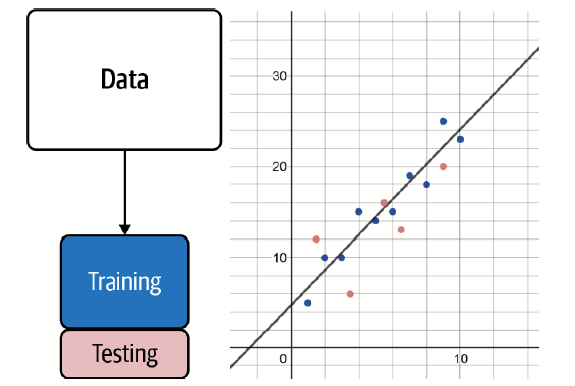

Рисунок 9. Разделение на данные обучения/тестирования — линия соответствует данным обучения.
(темно-синий) с использованием метода линейной регресии, а данные тестирования (светло-красный) анализируются позже, чтобы
посмотреть, насколько ошибочны прогнозы на данных, которых раньше не было.

Мы также можем чередовать тестовую выборку на каждом из треx подвыборок. Это называется кросс-валидацией и часто считается золотым стандартом методов валидации. На *рисунке 10* показано, как каждая треть данных принимает участие в качестве тестовой выборки.

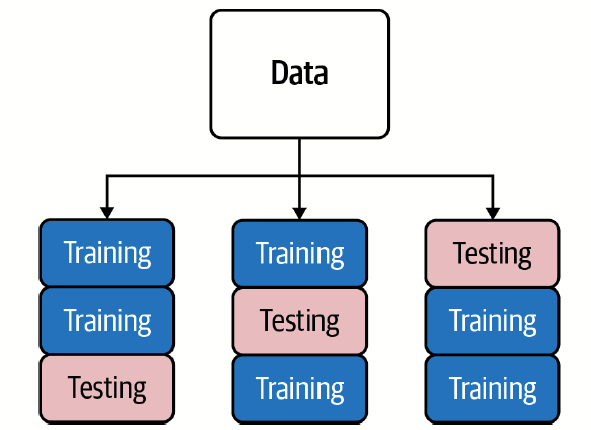

Рисунок 10. Визуализация кросс-валадиции с 3мя фолдами

# Кросс-валидация

*Пример 12* демонстрирует кросс-валидацию, выполненную по трём разбиениям данных (folds), с последующей усредненной оценкой метрики (в данном случае среднеквадратической ошибки, Mean Squared Error) и её стандартного отклонения.

In [ ]:
# Пример 12
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import pandas as pd

# Загрузка данных
df = pd.read_csv('https://bit.ly/3cIH97A', delimiter=",")

# Извлечение входных переменных (все строки, все столбцы кроме последнего)
X = df.iloc[:, :-1].values

# Извлечение выходной переменной (все строки, последний столбец)
Y = df.iloc[:, -1].values

# Настройка кросс-валидации с тремя разбиениями
kfold = KFold(n_splits=3, random_state=7, shuffle=True)
model = LinearRegression()

# Оценка модели с помощью кросс-валидации
results = cross_val_score(model, X, Y, cv=kfold, scoring='neg_mean_squared_error')
print("MSE: mean=%.3f (stdev=%.3f)" % (results.mean(), results.std()))

MSE: mean=-74.970 (stdev=4.129)


# Настройки кросс-валидации

Для валидации данных не обязательно делить их на трети. Вы можете использовать валидацию по любому количеству разбиений (folds). Значения `k`, такие как 3, 5 или 10, часто используются в зависимости от размера и сложности данных. Валидация методом "оставить одно" (Leave-one-out Cross-Validation, LOOCV) может быть полезной при небольшом размере набора данных.




Таким образом, когда у вас нет времени или ваши данные слишком объемны для детального статистического анализа, разделение на обучающие и тестовые выборки обеспечивает способ оценить, насколько хорошо линейная регрессия будет работать на новых данных.

# Множественная линейная регрессия

В этой лекуции мы почти полностью сосредоточились на выполнении **линейной регрессии** с одной входной переменной и одной выходной переменной. Однако концепции, которые мы изучили здесь, в значительной степени применимы и к многомерной линейной регрессии. Метрики, такие как $r^2$, стандартная ошибка и доверительные интервалы, могут использоваться, но их расчет усложняется с увеличением числа переменных. *Пример 13* демонстрирует линейную регрессию с двумя входными переменными и одной выходной переменной с использованием библиотеки **scikit-learn**.

In [ ]:
# Пример 13. Линейная регрессия с двумя входными переменными
import pandas as pd
from sklearn.linear_model import LinearRegression

# Загрузка данных
df = pd.read_csv('https://bit.ly/2X1HWH7', delimiter=",")

# Извлечение входных переменных (все строки, все столбцы кроме последнего)
X = df.iloc[:, :-1].values

# Извлечение выходной переменной (все строки, последний столбец)
Y = df.iloc[:, -1].values

# Обучение модели
fit = LinearRegression().fit(X, Y)

# Вывод коэффициентов
print("Coefficients = {0}".format(fit.coef_))
print("Intercept = {0}".format(fit.intercept_))
print("z = {0} + {1}x + {2}y".format(fit.intercept_, fit.coef_[0], fit.coef_[1]))

Coefficients = [2.00672647 3.00203798]
Intercept = 20.109432820035963
z = 20.109432820035963 + 2.006726472512807x + 3.0020379766466925y
